# FreeViz and SPCA: Quantitative Comparison

In this notebook, we compare FreeViz and SPCA classification accuracy
using 5-fold stratified cross-validation on three datasets.

- **FreeViz** is evaluated by training on the projected 2D space
  and predicting test labels via kNN (k=5).
- **SPCA Classification** is evaluated by projecting test data
  with the learned loadings and classifying with the learned linear classifier.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

import importlib
import utils
importlib.reload(utils)

from models import Freeviz
from models.spca_classification import SPCA_Classification
from utils import (
    load_zoo_data, load_mushroom_data, load_breast_cancer_data,
    scale_features, select_lambda
)

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/home/jasa/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
def run_cv(E_raw, C, class_names, dataset_name, n_splits=5):
    E = scale_features(E_raw)
    C_np = C.cpu().numpy()

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    freeviz_scores = []
    spca_scores = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(C_np, C_np)):
        E_train, E_test = E[train_idx], E[test_idx]
        C_train, C_test = C[train_idx], C[test_idx]

        fv = Freeviz(E.shape[1]).to(device)
        fv.train(E_train, C_train, print_loss=True)
        acc_fv = fv.accuracy(E_train, C_train, E_test, C_test).item()
        freeviz_scores.append(acc_fv)

        E_train_f64 = E_train.to(torch.float64)
        best_lam = select_lambda(
            SPCA_Classification, E_train_f64, C_train,
            num_classes=len(class_names), steps=500
        )

        train_mean = E_train.mean(dim=0)
        E_train_centered = E_train - train_mean
        model = SPCA_Classification(
            input_dim=E.shape[1], latent_dim=2,
            num_classes=len(class_names), lr=0.05
        ).to(device)
        model.train(E_train_centered, C_train,
                    lam=best_lam, steps=1000, classifier_epochs=50)

        E_test_centered = E_test - train_mean
        logits = model(E_test_centered)
        preds = torch.argmax(logits, dim=1)
        acc_spca = (preds == C_test).float().mean().item()
        spca_scores.append(acc_spca)

        print(f"\n===== {dataset_name} Fold {fold+1}: "
              f"FreeViz={acc_fv:.4f}, SPCA={acc_spca:.4f} =====\n")

    return freeviz_scores, spca_scores


def collect_results(name, fv_scores, spca_scores):
    return {
        "dataset": name,
        "fv_mean": np.mean(fv_scores),
        "spca_mean": np.mean(spca_scores),
    }

# ZOO dataset

In [4]:
E_zoo, C_zoo, names_zoo, feature_names_zoo, class_names_zoo = load_zoo_data(device)
fv_zoo, spca_zoo = run_cv(E_zoo, C_zoo, class_names_zoo, "ZOO")

/home/jasa/.local/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


step: 1 loss: 11526.3017578125
step: 2 loss: 14146.1767578125
step: 3 loss: 20850.283203125
step: 4 loss: 12669.2236328125
step: 5 loss: 11820.2216796875
step: 6 loss: 11154.240234375
step: 7 loss: 11187.3154296875
step: 8 loss: 10502.7490234375
step: 9 loss: 10513.3232421875
step: 10 loss: 14970.59375
step: 11 loss: 14896.880859375
Step 0: loss = 1.8426, classifier loss = 1.8378
Step 10: loss = 1.1139, classifier loss = 1.1069
Step 20: loss = 0.8290, classifier loss = 0.8212
Step 30: loss = 0.7015, classifier loss = 0.6934
Step 40: loss = 0.6182, classifier loss = 0.6099
Step 50: loss = 0.5414, classifier loss = 0.5325
Step 60: loss = 0.4700, classifier loss = 0.4602
Step 70: loss = 0.4117, classifier loss = 0.4014
Step 80: loss = 0.3637, classifier loss = 0.3532
Step 90: loss = 0.3235, classifier loss = 0.3128
Step 100: loss = 0.2895, classifier loss = 0.2785
Step 110: loss = 0.2604, classifier loss = 0.2493
Step 120: loss = 0.2355, classifier loss = 0.2242
Step 130: loss = 0.2140, c

# MUSHROOM dataset

In [5]:
E_mush, C_mush, names_mush, feature_names_mush, class_names_mush = load_mushroom_data(device)
fv_mush, spca_mush = run_cv(E_mush, C_mush, class_names_mush, "MUSHROOM")

step: 1 loss: 7173917.5
step: 2 loss: 1645241.125
step: 3 loss: 1637455.875
step: 4 loss: 1630081.0
step: 5 loss: 1616431.625
step: 6 loss: 1614432.25
step: 7 loss: 1601565.625
step: 8 loss: 1592961.875
step: 9 loss: 1578813.5
step: 10 loss: 1568150.375
step: 11 loss: 1553602.75
Step 0: loss = 1.1228, classifier loss = 0.6252
Step 10: loss = 0.8530, classifier loss = 0.3464
Step 20: loss = 0.7581, classifier loss = 0.2410
Step 30: loss = 0.7094, classifier loss = 0.1843
Step 40: loss = 0.6791, classifier loss = 0.1484
Step 50: loss = 0.6583, classifier loss = 0.1235
Step 60: loss = 0.6431, classifier loss = 0.1053
Step 70: loss = 0.6314, classifier loss = 0.0912
Step 80: loss = 0.6290, classifier loss = 0.0879
Step 90: loss = 0.6278, classifier loss = 0.0865
Step 100: loss = 0.6267, classifier loss = 0.0851
Step 110: loss = 0.6256, classifier loss = 0.0837
Step 120: loss = 0.6245, classifier loss = 0.0824
Step 130: loss = 0.6234, classifier loss = 0.0811
Step 140: loss = 0.6224, classi

# BREAST CANCER dataset

In [6]:
E_bc, C_bc, names_bc, feature_names_bc, class_names_bc = load_breast_cancer_data(device)
fv_bc, spca_bc = run_cv(E_bc, C_bc, class_names_bc, "BREAST CANCER")

step: 1 loss: 456138.90625
step: 2 loss: 593774.5
step: 3 loss: 564432.4375
step: 4 loss: 478267.625
step: 5 loss: 670413.3125
step: 6 loss: 502322.5
step: 7 loss: 478654.25
step: 8 loss: 434766.84375
step: 9 loss: 474567.3125
step: 10 loss: 413035.4375
step: 11 loss: 407944.40625
Step 0: loss = 0.6643, classifier loss = 0.6633
Step 10: loss = 0.5122, classifier loss = 0.5109
Step 20: loss = 0.4310, classifier loss = 0.4296
Step 30: loss = 0.3749, classifier loss = 0.3735
Step 40: loss = 0.3338, classifier loss = 0.3323
Step 50: loss = 0.3024, classifier loss = 0.3009
Step 60: loss = 0.2776, classifier loss = 0.2761
Step 70: loss = 0.2576, classifier loss = 0.2560
Step 80: loss = 0.2412, classifier loss = 0.2395
Step 90: loss = 0.2274, classifier loss = 0.2257
Step 100: loss = 0.2158, classifier loss = 0.2141
Step 110: loss = 0.2110, classifier loss = 0.2093
Step 120: loss = 0.2099, classifier loss = 0.2081
Step 130: loss = 0.2087, classifier loss = 0.2069
Step 140: loss = 0.2076, clas

# Summary

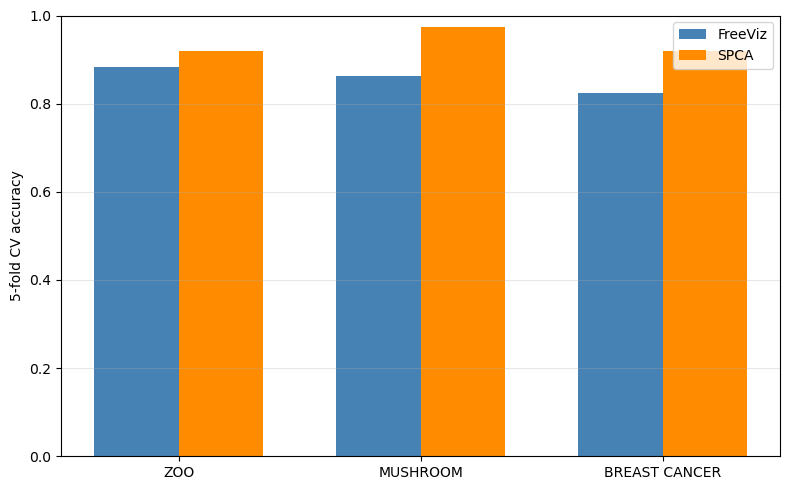

In [7]:
results = [
    collect_results("ZOO", fv_zoo, spca_zoo),
    collect_results("MUSHROOM", fv_mush, spca_mush),
    collect_results("BREAST CANCER", fv_bc, spca_bc),
]

datasets = [r["dataset"] for r in results]
x = np.arange(len(datasets))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, [r["fv_mean"] for r in results], w,
       label="FreeViz", color="steelblue")
ax.bar(x + w/2, [r["spca_mean"] for r in results], w,
       label="SPCA", color="darkorange")

ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_ylabel("5-fold CV accuracy")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()